In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df_assets = pd.read_csv("../data/processed/assets_clean.csv")
df_util = pd.read_csv("../data/processed/utilization_clean.csv")

print("Assets loaded:", df_assets.shape)
print("Utilization loaded:", df_util.shape)

Assets loaded: (85, 9)
Utilization loaded: (1530, 8)


In [3]:
device_counts = df_assets["Device_Type"].value_counts()
print(device_counts)

Device_Type
Access Point    40
Switch          20
Server          12
Router           8
Firewall         5
Name: count, dtype: int64


C:\Users\ARIB\AppData\Local\Temp\ipykernel_3452\480334741.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=device_counts.index, y=device_counts.values, palette="Blues_d")


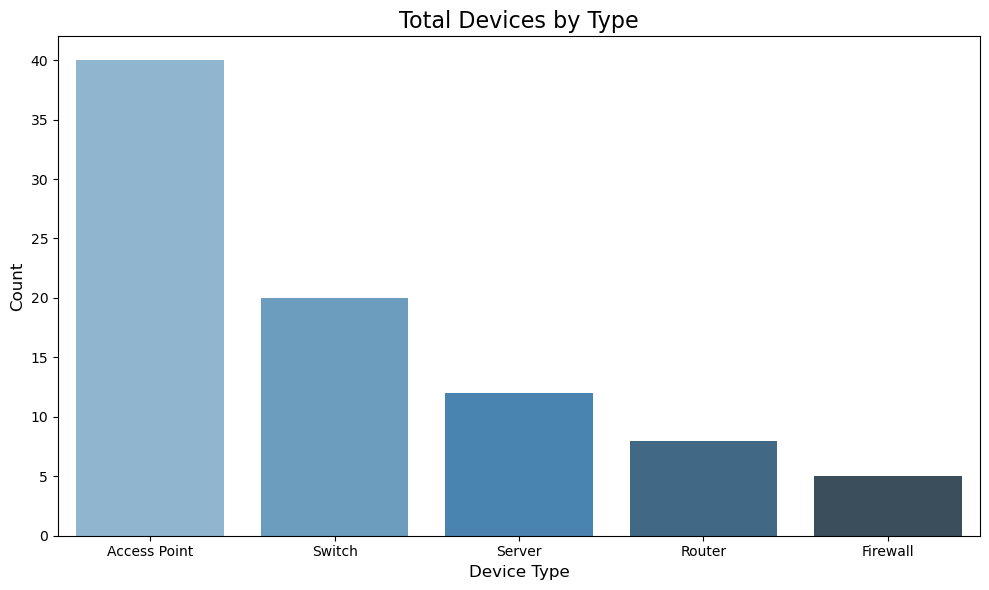

In [5]:
plt.figure(figsize=(10, 6))
sns.barplot(x=device_counts.index, y=device_counts.values, palette="Blues_d")
plt.title("Total Devices by Type", fontsize=16)
plt.xlabel("Device Type", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.tight_layout()
plt.savefig("../data/processed/devices_by_type.png")
plt.show()

In [7]:
location_counts = df_assets["Location"].value_counts()
print(location_counts)

Location
Block B - Floor 1    13
Cafeteria            13
Block A - Floor 1    13
Server Room          11
Block A - Floor 2     9
NOC                   7
Library               7
Block B - Floor 2     6
Data Center           6
Name: count, dtype: int64


C:\Users\ARIB\AppData\Local\Temp\ipykernel_3452\3496894838.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=location_counts.values, y=location_counts.index, palette="Greens_d")


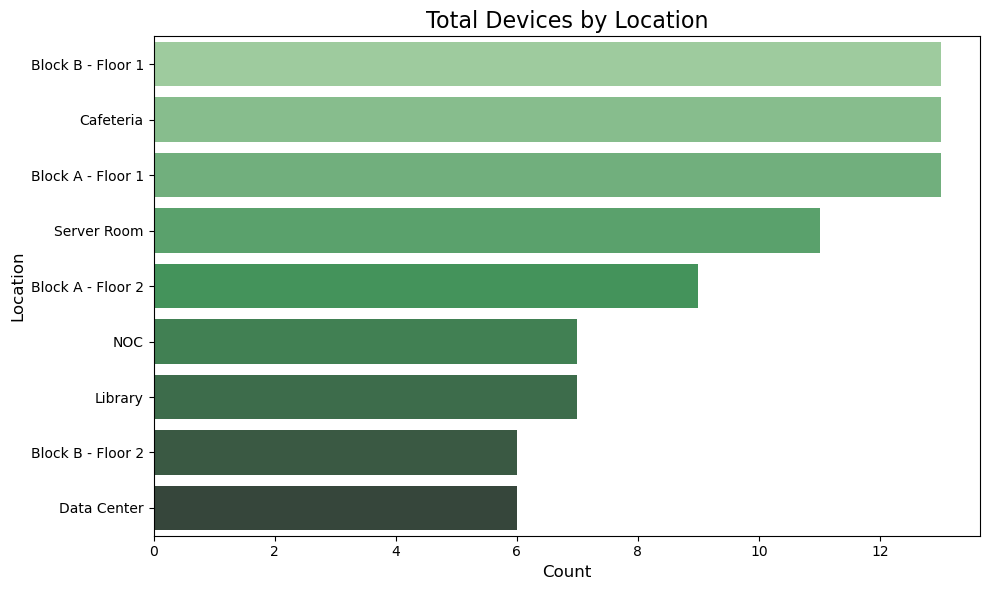

In [9]:
plt.figure(figsize=(10, 6))
sns.barplot(x=location_counts.values, y=location_counts.index, palette="Greens_d")
plt.title("Total Devices by Location", fontsize=16)
plt.xlabel("Count", fontsize=12)
plt.ylabel("Location", fontsize=12)
plt.tight_layout()
plt.savefig("../data/processed/devices_by_location.png")
plt.show()

In [11]:
warranty_counts = df_assets["Warranty_Status"].value_counts()
print(warranty_counts)

Warranty_Status
Expired    52
Active     33
Name: count, dtype: int64


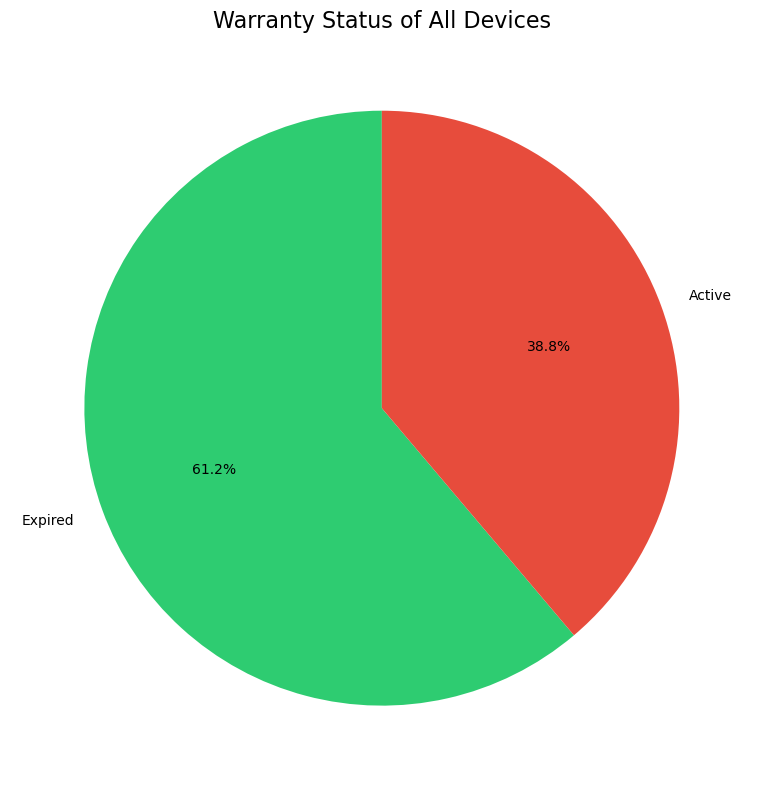

In [13]:
plt.figure(figsize=(8, 8))
plt.pie(warranty_counts.values, 
        labels=warranty_counts.index, 
        autopct="%1.1f%%",
        colors=["#2ecc71", "#e74c3c"],
        startangle=90)
plt.title("Warranty Status of All Devices", fontsize=16)
plt.tight_layout()
plt.savefig("../data/processed/warranty_status.png")
plt.show()

In [15]:
expired = df_assets[df_assets["Warranty_Status"] == "Expired"]
print(f"Total devices with expired warranty: {len(expired)}")
print("\n")
print(expired[["Asset_ID", "Device_Name", "Device_Type", "Manufacturer", "Location", "Warranty_Expiry"]])

Total devices with expired warranty: 52


    Asset_ID       Device_Name   Device_Type Manufacturer           Location  \
0   AST-1001       Router-1001        Router       Huawei  Block B - Floor 1   
1   AST-1002       Router-1002        Router        Cisco          Cafeteria   
2   AST-1003       Router-1003        Router        Cisco                NOC   
3   AST-1004       Router-1004        Router        Cisco          Cafeteria   
5   AST-1006       Router-1006        Router      Juniper  Block A - Floor 2   
6   AST-1007       Router-1007        Router       Huawei  Block A - Floor 2   
7   AST-1008       Router-1008        Router        Cisco        Server Room   
9   AST-1010       Switch-1010        Switch        Cisco        Server Room   
10  AST-1011       Switch-1011        Switch        Cisco  Block B - Floor 1   
11  AST-1012       Switch-1012        Switch        Aruba  Block B - Floor 2   
14  AST-1015       Switch-1015        Switch           HP  Block A - Floor 1  

In [17]:
print("Total expired devices:", len(expired))
print("Shape of expired table:", expired.shape)

Total expired devices: 52
Shape of expired table: (52, 9)


In [19]:
pd.set_option("display.max_rows", 100)
print(expired[["Asset_ID", "Device_Name", "Device_Type", "Manufacturer", "Location", "Warranty_Expiry"]])

    Asset_ID       Device_Name   Device_Type Manufacturer           Location  \
0   AST-1001       Router-1001        Router       Huawei  Block B - Floor 1   
1   AST-1002       Router-1002        Router        Cisco          Cafeteria   
2   AST-1003       Router-1003        Router        Cisco                NOC   
3   AST-1004       Router-1004        Router        Cisco          Cafeteria   
5   AST-1006       Router-1006        Router      Juniper  Block A - Floor 2   
6   AST-1007       Router-1007        Router       Huawei  Block A - Floor 2   
7   AST-1008       Router-1008        Router        Cisco        Server Room   
9   AST-1010       Switch-1010        Switch        Cisco        Server Room   
10  AST-1011       Switch-1011        Switch        Cisco  Block B - Floor 1   
11  AST-1012       Switch-1012        Switch        Aruba  Block B - Floor 2   
14  AST-1015       Switch-1015        Switch           HP  Block A - Floor 1   
15  AST-1016       Switch-1016        Sw

C:\Users\ARIB\AppData\Local\Temp\ipykernel_3452\1037952831.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=expired_by_location.values, y=expired_by_location.index, palette="Oranges_d")


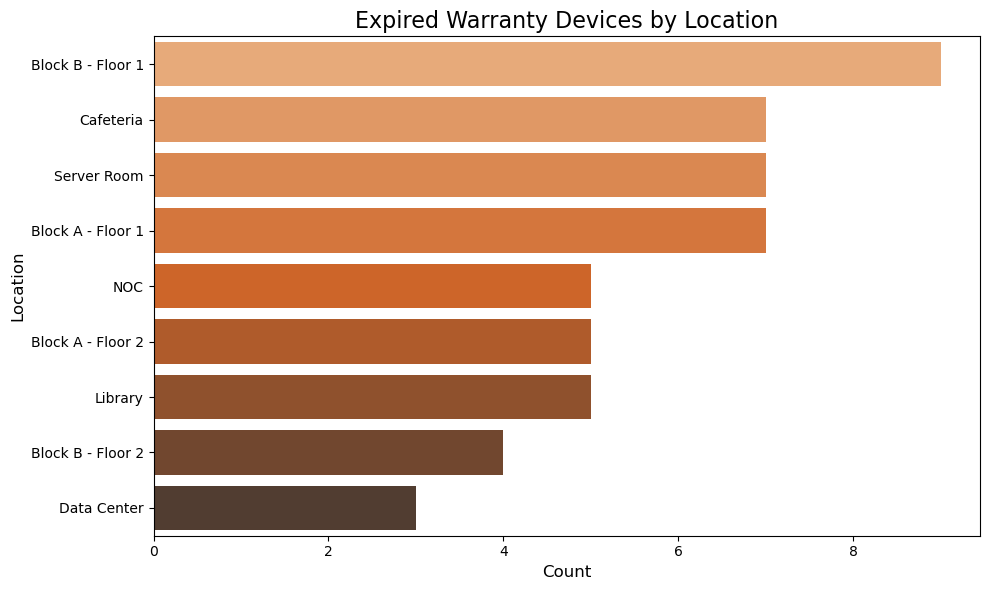

In [21]:
expired_by_location = expired["Location"].value_counts()

plt.figure(figsize=(10, 6))
sns.barplot(x=expired_by_location.values, y=expired_by_location.index, palette="Oranges_d")
plt.title("Expired Warranty Devices by Location", fontsize=16)
plt.xlabel("Count", fontsize=12)
plt.ylabel("Location", fontsize=12)
plt.tight_layout()
plt.savefig("../data/processed/expired_warranty_by_location.png")
plt.show()

In [23]:
print("=" * 45)
print("       INVENTORY ANALYSIS SUMMARY")
print("=" * 45)
print(f"Total Devices:              {len(df_assets)}")
print(f"Total Device Types:         {df_assets['Device_Type'].nunique()}")
print(f"Total Locations:            {df_assets['Location'].nunique()}")
print(f"Active Warranty Devices:    {len(df_assets[df_assets['Warranty_Status'] == 'Active'])}")
print(f"Expired Warranty Devices:   {len(df_assets[df_assets['Warranty_Status'] == 'Expired'])}")
print("=" * 45)

       INVENTORY ANALYSIS SUMMARY
Total Devices:              85
Total Device Types:         5
Total Locations:            9
Active Warranty Devices:    33
Expired Warranty Devices:   52
